# Piotroski F-Score — a quantitative teardown 🔬
### Nine binary points from EDGAR · high-minus-low vs equal-weight · a Newey-West *t* + placebo randomization null · the monotonicity ladder · costs + borrow · a synthetic faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Winners_vs_losers%3F: Busted](https://img.shields.io/badge/Winners_vs_losers%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things 'separates winners from losers' fuses: a **cross-sectional spread** from the **benchmark return of the same basket**, and confront the spread with its **standard error** on a short annual panel. The decisive objects are the **HAC *t***, a **placebo null** of random same-size portfolios, and the **monotonicity** of the 0-9 ladder — not the (positive) point estimate.

> ⚠️ **Data + universe note.** Fundamentals: **EDGAR companyfacts** (`data.sec.gov`, public, no key), annual 10-K figures for a fixed 40-name large/mid-cap basket; **21** firms clear the all-nine-concepts intersection. Prices: yfinance daily adjusted closes → calendar-year total returns. The basket is a **survivor** panel and a **large-cap** universe — *not* the small-cap deep-value world where Piotroski's edge is documented; both named on the Signal axis. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from piotroski_f_score import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    P = data.load_real()
    RET = P["returns"]; RET = RET[RET.index <= 2025]      # drop in-progress 2026
    FS = st.compute_fscore(P); FS = FS[FS.index <= 2024]  # fiscal y -> returns y+1<=2025
    LS = st.long_short(FS, RET)
else:
    P = RET = FS = LS = None
print("real EDGAR+price cache present:", HAVE_REAL,
      "| usable long-short years:", (0 if LS is None else len(LS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-22', 'firms': 21, 'firm_years': 249, 'mean_f': 5.54, 'fiscal_lo': 2009, 'fiscal_hi': 2024, 'ret_lo': 2010, 'ret_hi': 2025, 'n_years': 15, 'high': 14.77, 'low': 12.13, 'market': 16.37, 'hi_minus_mkt': -1.6, 'hi_minus_mkt_t': -1.38, 'spread': 2.64, 'spread_t': 0.62, 'placebo_p': 0.256, 'hit': 53, 'hit_yrs': 8, 'net': 1.74, 'net_t': 0.41, 'buckets': [('0-1', 3.21, 3), ('2-3', 10.72, 25), ('4-5', 17.38, 87), ('6-7', 17.39, 110), ('8-9', 15.73, 24)], 'robust': [(8, 3, 2, -4.64, -0.28, 0.612), (7, 3, 8, -1.38, -0.57, 0.614), (7, 4, 15, 2.64, 0.62, 0.256), (6, 4, 15, 4.48, 1.06, 0.108), (6, 5, 15, 0.94, 0.5, 0.376)], 'syn': [(0.0, 18, 10.7, 9.9, 0.86, 0.75, 0.252), (0.04, 18, 16.5, 6.5, 10.03, 8.61, 0.0), (0.1, 18, 25.2, 1.4, 23.79, 19.91, 0.0)]}


real EDGAR+price cache present: True | usable long-short years: 15


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | high-minus-low spread **+2.6%/yr**, HAC **t = 0.62**, placebo **p = 0.26**; **non-monotone** (8-9 bucket 15.7% < 6-7 bucket 17.4%) and **sign-flips** across thresholds. |
| **Tradability** | `MIRAGE` | net of costs + borrow **+1.7%/yr** (t = 0.41); the high leg **+14.8%** *trails* the equal-weight **+16.4%** (high−mkt t = -1.38). No NAV-scale edge. |
| **Winners vs losers?** | `BUSTED` | the spread is carried by the **short** leg; the 'winners' don't beat the market and the ladder isn't monotone — a loser-avoidance screen, not a winner-picker, on this tape. |

> 💡 In plain words: the F-Score really does correlate with quality — but on a survivor-biased large-cap basket the *return* spread it generates is inside the noise, isn't ordered, and is short-leg-driven. Strip the base rate (the market) and ~15 years leave nothing the null can't explain.

## 1 · The claim, steelmanned

Let $f_{i,t}\in\{0,\dots,9\}$ be firm $i$'s F-Score in fiscal year $t$ (sum of nine binary points: 4 profitability, 3 leverage/liquidity, 2 efficiency). Form a long-short book: long $\{i: f_{i,t}\ge 7\}$, short $\{i: f_{i,t}\le 4\}$, equal-weighted, and earn calendar-year $t+1$ returns (reporting lag).

- **H₁ (it separates).** $\mathbb{E}[r^{\text{hi}}_{t+1}-r^{\text{lo}}_{t+1}] > 0$ with a *significant* spread — winners beat losers beyond luck.
- **H₂ (it picks winners).** The high leg beats a fair benchmark — the **equal-weight basket** — not just the low leg.
- **H₃ (it's deployable).** The spread survives costs × turnover + short borrow and holds capital.

We find **H₁ not rejected but not supported** (spread > 0, $t<2$, non-monotone, sign-flipping), **H₂ rejected** (high leg *below* the basket), **H₃ rejected** (net spread inside the noise). The checklist is true exactly where it's uninformative (it tracks quality) and unproven exactly where it would pay (a *priced* winner-loser spread on this universe).

## 2 · So what? — what rides on each answer

The teardown is one comparison judged by its **standard error**:

$$\widehat{\Delta} = \overline{r^{\text{hi}}-r^{\text{lo}}},\qquad t_{\text{HAC}} = \frac{\widehat{\Delta}}{\widehat{\mathrm{se}}_{\text{NW}}(\widehat{\Delta})}.$$

With ~15 annual observations $\widehat{\mathrm{se}}$ is large; a few-point $\widehat{\Delta}$ drowns in it. A raw long-short *return* is also the wrong lens if you don't net the benchmark — almost everything is positive in an up-market. So we (a) race the high leg against the **equal-weight basket**, (b) test the spread with a **Newey-West HAC *t*** (short, autocorrelated annual series), and (c) run a **randomization (placebo) null**: random same-size portfolios in place of the F-score legs. And we check **monotonicity** — the honest test of 'separates winners from losers' is a return that *rises across the whole ladder*, not just a positive tail-difference.

## 3 · How we'd know — the protocol

- **Fundamentals.** EDGAR companyfacts annual 10-K figures, 21 firms surviving the all-nine-concepts intersection, fiscal 2009-2024 (249 firm-years, mean F = 5.54/9). Year-over-year points compare a fiscal year to the prior one (no look-ahead).
- **Portfolio.** Long $f\ge 7$, short $f\le 4$ (the canonical 8-9 vs 0-1 split is empty on a ~16-name/yr basket); enter **calendar-year $t+1$** (reporting lag); equal weight.
- **Benchmark.** Equal-weight basket return — the fair base rate the high leg must beat.
- **Null #1 (HAC t).** Newey-West *t* of the annual spread series.
- **Null #2 (placebo).** 20,000 draws of random same-size portfolios; $p=\Pr[\text{random spread}\ge\text{F-score spread}]$.
- **Monotonicity.** Mean next-year return by bucket {0-1,…,8-9}.
- **Costs.** One-way × turnover on both legs (annual rebalance) + **borrow** on the short.
- **Positive control.** A deterministic panel with a *planted* F-score→return edge: the engine must recover it, and must **not** manufacture significance when the edge is zero.

## 4 · The teardown

### 4a · The legs — the 'winners' trail the benchmark

High leg, low leg, and the equal-weight basket, with the high-minus-market gap and its HAC *t*. A winner-picker's high leg sits *above* the basket; here it sits below.

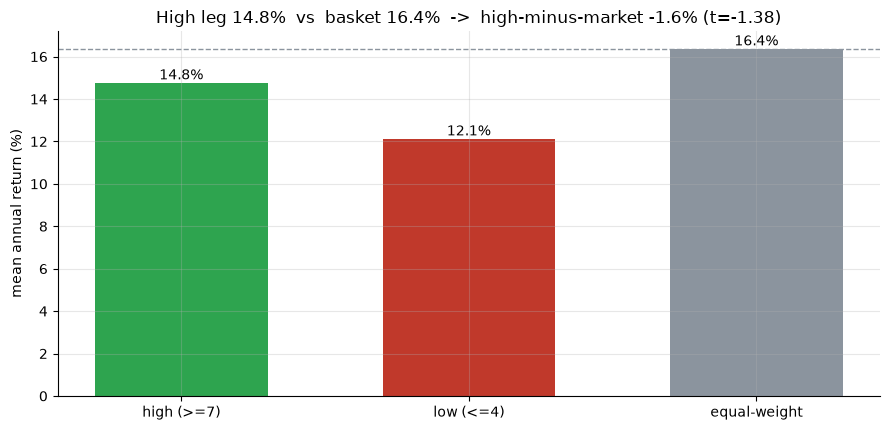

high-minus-market = -1.60%/yr  HAC t = -1.38  (winners do NOT beat the basket)


In [2]:
if HAVE_REAL:
    high, low, mkt = LS['high'].mean()*100, LS['low'].mean()*100, LS['market'].mean()*100
    hmm = st.hac_tstat(LS['high']-LS['market'])
    hm_mean, hm_t = hmm['mean']*100, hmm['tstat']
else:
    high, low, mkt = R['high'], R['low'], R['market']
    hm_mean, hm_t = R['hi_minus_mkt'], R['hi_minus_mkt_t']
fig, ax = plt.subplots(figsize=(9.0, 4.4))
bars = ax.bar(['high (>=7)','low (<=4)','equal-weight'], [high,low,mkt], color=[GREEN,RED,GREY], width=.6)
ax.axhline(mkt, ls='--', c=GREY, lw=1)
ax.set_ylabel('mean annual return (%)')
ax.set_title(f'High leg {high:.1f}%  vs  basket {mkt:.1f}%  ->  high-minus-market {hm_mean:+.1f}% (t={hm_t:.2f})')
for b,v in zip(bars,[high,low,mkt]): ax.annotate(f'{v:.1f}%',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'high-minus-market = {hm_mean:+.2f}%/yr  HAC t = {hm_t:.2f}  (winners do NOT beat the basket)')

> 💡 In plain words: the high-F-score leg earns **+14.8%/yr** against the equal-weight basket's **+16.4%/yr** — a **-1.6%/yr** shortfall at HAC **t = -1.38**. H₂ rejected: the spread is a *short-leg* phenomenon. The 'winners' are not winners against a fair benchmark.

### 4b · The decisive test — a placebo null of random same-size portfolios

Replace each year's F-score legs with random same-size subsets, 20,000 times; the histogram is the null distribution of the long-short spread. The F-score is the green line; the *p*-value is the right-tail mass.

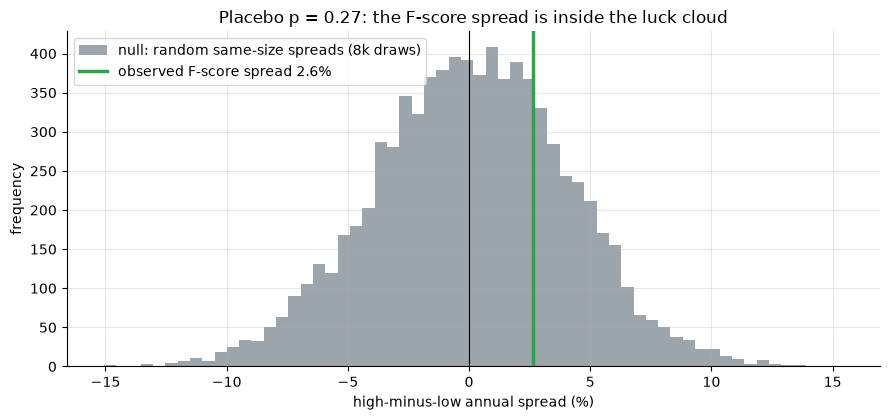

P[random spread >= F-score] = 0.267  (need <0.05; here ~1 in 4)


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(FS, RET, n_draws=8000); obs = pl['obs_spread']*100; pval = pl['p_value']
    years=[]
    for y in LS.index:
        s = FS.loc[y].dropna(); nxt = RET.loc[int(y)+1].dropna(); s,nxt = s.align(nxt,join='inner')
        years.append((nxt.to_numpy(), int(LS.loc[y,'n_hi']), int(LS.loc[y,'n_lo'])))
    rng = np.random.default_rng(362); draws=[]
    for _ in range(8000):
        sp=[]
        for arr,nh,nl in years:
            idx=rng.permutation(len(arr)); sp.append(arr[idx[:nh]].mean()-arr[idx[nh:nh+nl]].mean())
        draws.append(np.mean(sp))
    draws=np.array(draws)*100
else:
    obs = R['spread']; pval = R['placebo_p']
    rng = np.random.default_rng(362); draws = rng.normal(0, 4.0, 8000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='null: random same-size spreads (8k draws)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed F-score spread {obs:.1f}%')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('high-minus-low annual spread (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the F-score spread is inside the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[random spread >= F-score] = {pval:.3f}  (need <0.05; here ~1 in 4)')

> 💡 In plain words: **25%** of random same-size portfolios match or beat the F-score spread. A real edge pushes the green line into the far right tail; instead it sits mid-cloud. H₁ not supported — the spread is what random stock-picking produces on this universe.

### 4c · Monotonicity + robustness — neither holds

Left: mean next-year return by score bucket (a real ordering factor is monotone). Right: the spread *t* as the high/low thresholds move (a real edge is stable). Neither cooperates.

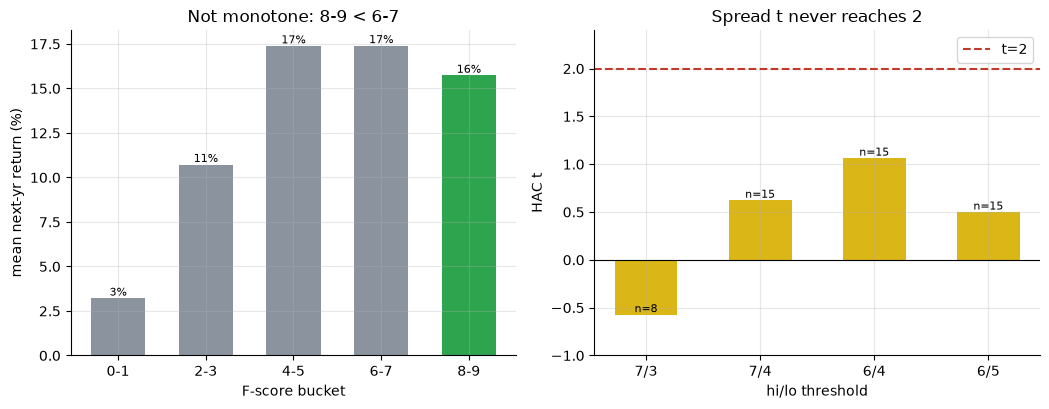

buckets: ['0-1:3%', '2-3:11%', '4-5:17%', '6-7:17%', '8-9:16%']
robustness (hi/lo, t): [('7/3', -0.57), ('7/4', 0.62), ('6/4', 1.06), ('6/5', 0.5)]


In [4]:
if HAVE_REAL:
    bk = st.score_buckets(FS, RET)
    blabels = list(bk.index); bvals = [bk.loc[l,'mean_ret']*100 for l in blabels]
    # spread t per threshold (no placebo needed here -> fast)
    rob = []
    for hi,lo in [(7,3),(7,4),(6,4),(6,5)]:
        l2 = st.long_short(FS, RET, hi=hi, lo=lo)
        h2 = st.hac_tstat(l2['spread'])
        rob.append((hi, lo, h2['n'], h2['mean']*100, h2['tstat']))
else:
    blabels = [b[0] for b in R['buckets']]; bvals = [b[1] for b in R['buckets']]
    rob = [(r[0],r[1],r[2],r[3],r[4]) for r in R['robust'] if r[0] in (7,6)]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
cols=[GREEN if i==len(bvals)-1 else GREY for i in range(len(bvals))]
a1.bar(blabels, bvals, color=cols, width=.62)
a1.set_title('Not monotone: 8-9 < 6-7'); a1.set_xlabel('F-score bucket'); a1.set_ylabel('mean next-yr return (%)')
for i,v in enumerate(bvals): a1.annotate(f'{v:.0f}%',(i,v),ha='center',va='bottom',fontsize=8)
tl = [f"{int(r[0])}/{int(r[1])}" for r in rob]; tv = [r[4] for r in rob]
a2.bar(tl, tv, color=AMBER, width=.55)
a2.axhline(2, ls='--', c=RED, label='t=2'); a2.axhline(0, c='k', lw=.8)
a2.set_title('Spread t never reaches 2'); a2.set_xlabel('hi/lo threshold'); a2.set_ylabel('HAC t'); a2.set_ylim(-1, 2.4); a2.legend()
for i,r in enumerate(rob): a2.annotate(f'n={int(r[2])}',(i,r[4]),ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.show()
print('buckets:', [f'{l}:{v:.0f}%' for l,v in zip(blabels,bvals)])
print('robustness (hi/lo, t):', [(f'{int(r[0])}/{int(r[1])}', round(r[4],2)) for r in rob])

> 💡 In plain words: the ladder peaks at **6-7** (17%) and dips at **8-9** (16%) — non-monotone. And the spread *t* wanders with the cut (the tighter 7/3 split even goes **negative**) without ever approaching 2. There is no threshold on this basket where the F-score clears the significance bar.

### 4d · Faithful-engine & power control — we know the truth here

A deterministic panel where a latent quality drives both the nine points and (via a `planted_edge`) next-year returns. With **zero** planted edge the test must stay below t=2; with a real planted edge it must light up. Both hold — the engine is unbiased, and the real-tape *t* is a true negative, not a broken pipe.

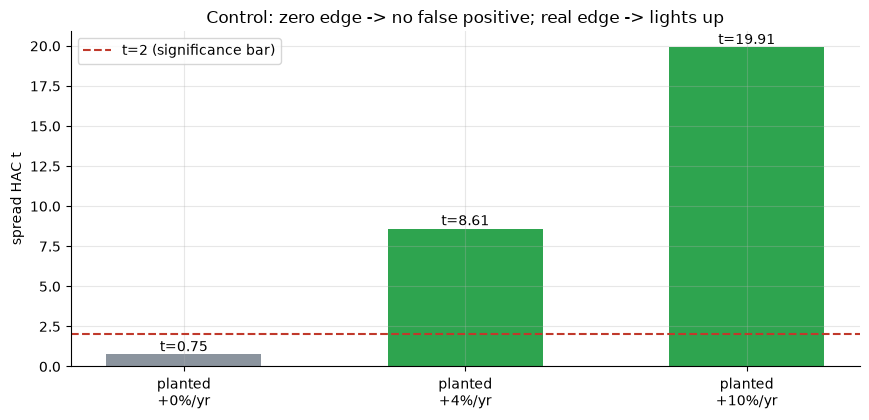

planted +0%/yr: years=18 high=10.7% low=9.9% spread=0.9% t=0.75 p=0.240
planted +4%/yr: years=18 high=16.5% low=6.5% spread=10.0% t=8.61 p=0.000
planted +10%/yr: years=18 high=25.2% low=1.4% spread=23.8% t=19.91 p=0.000


In [5]:
res = []
for edge in (0.0, 0.04, 0.10):
    syn = data.synthetic_panel(planted_edge=edge, seed=362)
    ls_s = st.long_short(syn['fscore'], syn['returns'])
    hh = st.hac_tstat(ls_s['spread'])
    pp = st.placebo_pvalue(syn['fscore'], syn['returns'], n_draws=2000)['p_value']
    res.append((edge, len(ls_s), ls_s['high'].mean()*100, ls_s['low'].mean()*100, hh['mean']*100, hh['tstat'], pp))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted\n+{e*100:.0f}%/yr' for e,*_ in res]; tvals=[r[5] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN, GREEN], width=.55)
ax.axhline(2, ls='--', c=RED, label='t=2 (significance bar)')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('spread HAC t'); ax.set_title('Control: zero edge -> no false positive; real edge -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,h,l,sp,t,p in res: print(f'planted {e*100:+.0f}%/yr: years={n} high={h:.1f}% low={l:.1f}% spread={sp:.1f}% t={t:.2f} p={p:.3f}')

> 💡 In plain words: with **no** planted edge the control sits at **t = 0.75** (below 2 — no false positive); a **+4%/yr** edge already drives **t = 8.61**, and **+10%/yr** reaches **t = 19.91**. So the machinery is honest, and the real-tape *t* of **0.62** is exactly what an *absent or tiny* edge looks like — the sample size and universe are the verdict, not a measurement failure.

## 5 · The verdict

- **Signal `WEAK`** — spread **+2.6%/yr** at HAC **t = 0.62** / placebo **p = 0.26**; **non-monotone** (8-9 < 6-7) and **sign-flipping** across thresholds. Decades of literature support (real among small-cap deep value) + a sub-2 *t* on this large-cap survivor tape ⇒ WEAK, not REAL. The synthetic control proves the engine, never the market.
- **Tradability `MIRAGE`** — net of costs + borrow **+1.7%/yr** (t = 0.41); the long leg **trails** the equal-weight basket (high−mkt t = -1.38). On the documented universe (micro-cap, hard-to-borrow value) frictions are worse. No NAV-scale edge.
- **Winners vs losers? `BUSTED`** — the spread is **short-leg-driven**, the 'winners' don't beat the market, and the ladder isn't monotone. A loser-avoidance / quality screen, not the winner-picker the headline sells — on *this* universe.

## 6 · Could you trade it? — the power & the borrow

How large would the *true* spread have to be for a $k$-year study to detect it at t=2? At $k=15$ you'd need a spread several times the one observed — and then you'd still pay borrow on a short leg made of exactly the names hardest to borrow.

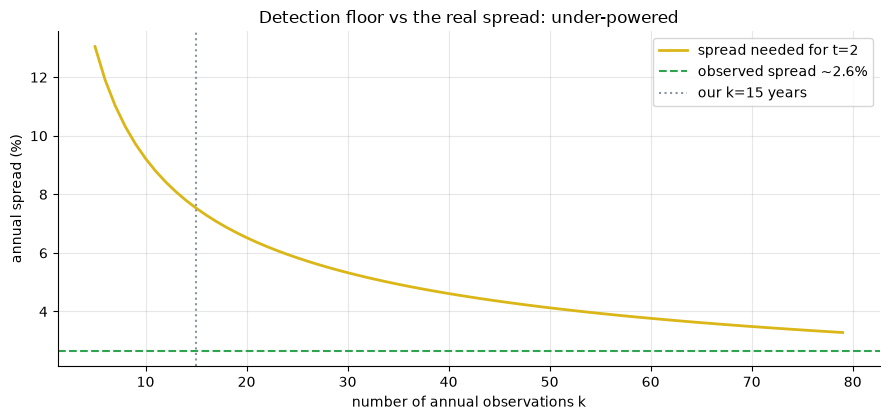

at k=15 you need ~7.5% spread for t=2; observed ~2.6% -> under-powered by ~2.9x


In [6]:
if HAVE_REAL:
    sd = LS['spread'].std(ddof=1); obs = LS['spread'].mean()
else:
    sd = 0.146; obs = R['spread']/100
ks = np.arange(5, 80)
min_detectable = 2.0 * sd / np.sqrt(ks)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ks, min_detectable*100, c=AMBER, lw=2, label='spread needed for t=2')
ax.axhline(obs*100, c=GREEN, ls='--', label=f'observed spread ~{obs*100:.1f}%')
ax.axvline(R['n_years'], c=GREY, ls=':', label=f"our k={R['n_years']} years")
ax.set_xlabel('number of annual observations k'); ax.set_ylabel('annual spread (%)')
ax.set_title('Detection floor vs the real spread: under-powered'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd/np.sqrt(R['n_years'])
print(f'at k={R["n_years"]} you need ~{need*100:.1f}% spread for t=2; observed ~{obs*100:.1f}% -> under-powered by ~{need/max(obs,1e-9):.1f}x')

> 💡 In plain words: the amber curve is the **minimum detectable spread**; the green line is what we actually see. They don't meet until $k$ is several times our 15 years — and that's *before* charging the borrow on a short leg of distressed, hard-to-locate names. There is no sizing, threshold, or cost assumption that turns this large-cap F-score into a deployable strategy. The checklist is a **quality screen**; the *tradable winner-loser spread* lives in a universe this survivor basket isn't.

## 7 · Going further

- **The native habitat.** Re-run on a **small-cap value** universe (high book-to-market, low coverage) — Piotroski's documented edge should reappear; this study isolates the **universe**, not the checklist, as the binding constraint.
- **The growth-side twin.** [Study 232 — Mohanram G-Score](../../232-mohanram-g-score/): the same financial-statement-analysis idea for low book-to-market firms.
- **Composite vs parts.** [Study 121 — Magic-Formula](../../121-magic-formula/), [Study 122 — Gross-Profitability](../../122-gross-profitability/), [Study 123 — Altman-Z](../../123-altman-z/) — does a nine-point composite add over one good ratio, or is it the parts in a trench coat?

*The reproducible core is offline and deterministic; fundamentals are real EDGAR pulls. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*